<div style=" background-color: RGB(35,114,00);" >
<h1 style="margin: auto; padding: 60px 0; color:#fff; text-align: center">ANALYSE DES VENTES D'UNE LIBRAIRIE</h1>
</div>

<h2 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) ">I - Nettoyage et traitement des tables </h2>

<h3 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.1- Chargement des librairies et définition des fonctions </h3>


In [216]:
# Importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

In [8]:
# Défininir d'une fonction qui affiche la distribution de la variable

def distribution_variable (
    data_frame: pd.DataFrame,
    var: str = "price",
    xlabel: str = "Densité",
    ylabel: str = "valeur",
    title: str = "show title",
    fig_dimension: tuple = (12, 6)) -> None:

    # Extraire la colonne 
    variable = data_frame[var].dropna()

    # Calculer la moyenne et l'écart type
    mean_variable = variable.mean()
    std_variable = variable.std()
    
    # Afficher les valeurs calculées
    print(f"Moyenne variable : {mean_variable}")
    print(f"Écart type de la variable : {std_variable}")
    
    # Tracer l'histogramme avec une courbe gaussienne
    plt.figure(figsize=fig_dimension)
    
    # Histogramme
    
    plt.hist(variable, bins=10, density=True, color='skyblue', edgecolor='black', alpha=0.6)
    
    # Ajustement gaussien
    mu, std = norm.fit(variable)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, variable.count())
    p = norm.pdf(x, mu, std)
    
    # Tracer la courbe gaussienne
    plt.plot(x, p, 'k', linewidth=2, label='Ajustement Gaussien')
    
    # Ajouter les titres et légendes en français
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    
    # Afficher le graphique
    plt.show()

<h3 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.2- Analyse de la table customers </h3>

<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.2.1- Description de la table </h4>

In [11]:
# Charger et décrire la table customers 

df_cust = pd.read_csv("customers.csv")

df_cust.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8623 entries, 0 to 8622
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8623 non-null   object
 1   sex        8623 non-null   object
 2   birth      8623 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [12]:
# Afficher la table

df_cust

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943
...,...,...,...
8618,c_7920,m,1956
8619,c_7403,f,1970
8620,c_5119,m,1974
8621,c_5643,f,1968


<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.2.2- Recherche des anomalies </h4>

In [14]:

# Définir une liste d'identifiant unique

id_unique = df_cust["client_id"].unique().tolist()

# Rechercher les identifiants en double

print("On observe", len(id_unique), "identifiants uniques. Soit le nombre total de lignes de la table df_cust")

On observe 8623 identifiants uniques. Soit le nombre total de lignes de la table df_cust


In [15]:
# 2e méthode de vérification de l'existence des doublons

mask = df_cust["client_id"].duplicated(keep=False)

df_cust.loc[mask, :]

,client_id,sex,birth


In [16]:
# Imprimer les identifiants client qui ne sont pas au bon format

for id in id_unique:
    if "c_" not in id:
        print(id)

ct_0
ct_1


In [17]:
# Afficher les informations sur les clients avec un identifiant atypique

df_cust.loc[df_cust["client_id"].isin(["ct_0", "ct_1"]), :]

,client_id,sex,birth
2735,ct_0,f,2001
8494,ct_1,m,2001


In [18]:
# Supprimer les deux observations avec les identifiants atypiques 
mask_indices = ~df_cust.index.isin([2735, 8494])

df_cust = df_cust[mask_indices]


# Vérifier s'il existe des anomalies dans la variable sex

print("Les modalités de la variables sex sont: ", df_cust["sex"].unique().tolist())


# Vérifier s'il existe des anomalies dans la variable birth

print("Les modalités de la variables birth sont: ", df_cust["birth"].unique().tolist())

Les modalités de la variables sex sont:  ['f', 'm']
Les modalités de la variables birth sont:  [1967, 1975, 1984, 1962, 1943, 1993, 1978, 1971, 1982, 1945, 2003, 1959, 1977, 1954, 1987, 2000, 1992, 1963, 1958, 1994, 1936, 1986, 1942, 1970, 1957, 1968, 2002, 2004, 1979, 1974, 1964, 1951, 1937, 1981, 1965, 1960, 1996, 1983, 1990, 1955, 1988, 1991, 1972, 1980, 1989, 1976, 1985, 1953, 1998, 1956, 1948, 1973, 1969, 1938, 1995, 1952, 1949, 1999, 2001, 1939, 1950, 1966, 1935, 1941, 1961, 1997, 1944, 1929, 1947, 1946, 1932, 1931, 1933, 1930, 1940, 1934]


In [19]:
# Sauvegarder la table customers

df_cust.to_csv("df_customers", index = False)

<h3 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.3- Analyse de la table products </h3>

<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.3.1- Description de la table </h4>

In [22]:
# Charger la table 

df_prod = pd.read_csv("products.csv")

budgets = df_prod['price'].dropna()


# Afficher la table 

df_prod

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0
...,...,...,...
3282,2_23,115.99,2
3283,0_146,17.14,0
3284,0_802,11.22,0
3285,1_140,38.56,1


In [23]:
# Décrire  la table

df_prod.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3287 non-null   object 
 1   price    3287 non-null   float64
 2   categ    3287 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.2+ KB


<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.3.2- Recherche des anomalies </h4>

In [25]:
# Vérifier l'existence d'identifiants produit en double

mask = df_prod["id_prod"].duplicated(keep=False)

df_prod.loc[mask, :]

,id_prod,price,categ


On n'observe pas d'identifiants en  double

In [27]:
# Rechercher les valeurs de l'identifiant id_prod atypique et donc ne commencant pas par un chiffre

liste_id_prod = df_prod["id_prod"].unique().tolist()

for id in liste_id_prod:
    if  id[0]  not in ("0", "1", "2", "3", "4", "5", "6"):
        print(id)


T_0


In [28]:
# Identifier les anomalies sur la variable price

df_prod["price"].describe()

count    3287.000000
mean       21.856641
std        29.847908
min        -1.000000
25%         6.990000
50%        13.060000
75%        22.990000
max       300.000000
Name: price, dtype: float64

In [29]:
# Afficher les données avec des prix négatifs 

df_prod.loc[df_prod["price"] < 0, :]

,id_prod,price,categ
731,T_0,-1.0,0


On observe une seule observation avec un prix négatif. Cette observation dispose d'une valeur id_prod atypique, soit  T_0. Cette observation sera donc supprimée. 

In [31]:
# Supprimer les observations avec le prix négatif

mask_indices = ~df_prod.index.isin([731])

df_prod= df_prod[mask_indices]


# Modalités de la variable categ

print(df_prod["categ"].unique().tolist())


[0, 1, 2]


In [32]:
# Créeer une nouvelle variable de la catégorie de produit
 
pd.options.mode.copy_on_write = True 

df_prod["categorie_produit"] = "NA"

df_prod.loc[df_prod["categ"] == 0, ["categorie_produit"]] = "catégorie 0"
df_prod.loc[df_prod["categ"] == 1, ["categorie_produit"]] = "catégorie 1"
df_prod.loc[df_prod["categ"] == 2, ["categorie_produit"]] = "catégorie 2"

df_prod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3286 entries, 0 to 3286
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_prod            3286 non-null   object 
 1   price              3286 non-null   float64
 2   categ              3286 non-null   int64  
 3   categorie_produit  3286 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 128.4+ KB


In [33]:
# Sauvegarder la table 

df_prod.to_csv("df_productions", index = False)

<h3 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.4- Analyse de la table transaction </h3>

<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.4.1- Description de la table </h4>

In [419]:
# Charger la table 

df_trans = pd.read_csv("transactions.csv")


# Afficher la table

df_trans

,id_prod,date,session_id,client_id
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232
...,...,...,...,...
679527,0_1551,2022-01-15 13:05:06.246925,s_150195,c_8489
679528,1_639,2022-03-19 16:03:23.429229,s_181434,c_4370
679529,0_1425,2022-12-20 04:33:37.584749,s_314704,c_304
679530,0_1994,2021-07-16 20:36:35.350579,s_63204,c_2227


In [421]:
# Décrire la table

df_trans.info()

df_trans.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679532 entries, 0 to 679531
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     679532 non-null  object
 1   date        679532 non-null  object
 2   session_id  679532 non-null  object
 3   client_id   679532 non-null  object
dtypes: object(4)
memory usage: 20.7+ MB


,id_prod,date,session_id,client_id
count,679532,679532,679532,679532
unique,3267,679371,342316,8602
top,1_369,test_2021-03-01 02:30:02.237413,s_0,c_1609
freq,2252,13,200,25488


<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.4.2- Recherche des anomalies </h4>

In [423]:
# Identifier les doublons

mask = df_trans["session_id"].duplicated(keep=False)

df_count = df_trans.loc[mask, : ].value_counts().reset_index()


# Afficher les observations avec l'identifiant session_id en double

df_count.loc[df_count["count"] >1, :].head(10)

,id_prod,date,session_id,client_id,count
0,T_0,test_2021-03-01 02:30:02.237413,s_0,ct_0,9
1,T_0,test_2021-03-01 02:30:02.237428,s_0,ct_0,6
2,T_0,test_2021-03-01 02:30:02.237446,s_0,ct_0,6
3,T_0,test_2021-03-01 02:30:02.237412,s_0,ct_1,5
4,T_0,test_2021-03-01 02:30:02.237414,s_0,ct_1,5
5,T_0,test_2021-03-01 02:30:02.237443,s_0,ct_1,5
6,T_0,test_2021-03-01 02:30:02.237427,s_0,ct_1,4
7,T_0,test_2021-03-01 02:30:02.237441,s_0,ct_0,4
8,T_0,test_2021-03-01 02:30:02.237430,s_0,ct_1,4
9,T_0,test_2021-03-01 02:30:02.237432,s_0,ct_0,4


In [425]:
# Afficher les observations avec l'identifiant session_id unique

df_count.loc[df_count["count"] ==1, :]

,id_prod,date,session_id,client_id,count
57,1_147,2021-06-14 13:19:42.305640,s_48567,c_6526,1
58,1_145,2023-02-27 23:14:27.205591,s_347946,c_2586,1
59,1_146,2021-07-22 04:11:29.144620,s_65518,c_4435,1
60,1_146,2021-12-31 05:01:22.475539,s_142694,c_4491,1
61,1_147,2021-03-05 08:23:35.615501,s_2010,c_6621,1
...,...,...,...,...,...
516051,0_1465,2022-08-28 09:00:47.122476,s_259666,c_2908,1
516052,0_1465,2022-08-27 23:13:47.407368,s_259443,c_8035,1
516053,0_1465,2022-08-26 09:32:51.358989,s_258678,c_2146,1
516054,0_1465,2022-08-26 00:46:53.348407,s_258488,c_1789,1


Les observations avec un identifiant session en double correspondent aux observations avec l'id produit atypique. soit T_0. Cette observation a été supprimée dans la table de production. nous décidons de la supprimer également dans la table des transaction 

In [427]:
# Supprimer les transactions correspondant à l'id prod T_0

df_trans = df_trans.loc[df_trans["id_prod"] != "T_0", : ].copy()

In [429]:
# Vérifier à nouveau s'il existe des observations avec la variable session_id en double

mask = df_trans["session_id"].duplicated(keep=False)

df_count2 = df_trans.loc[mask, : ].value_counts().reset_index()

df_count2.loc[df_count2["count"] >1, :]


,id_prod,date,session_id,client_id,count


In [431]:
# Vérifier s'il existe des anomalies sur la variable date

pd.to_datetime(df_trans["date"])


0        2022-05-20 13:21:29.043970
1        2022-02-02 07:55:19.149409
2        2022-06-18 15:44:33.155329
3        2021-06-24 04:19:29.835891
4        2023-01-11 08:22:08.194479
                    ...            
679527   2022-01-15 13:05:06.246925
679528   2022-03-19 16:03:23.429229
679529   2022-12-20 04:33:37.584749
679530   2021-07-16 20:36:35.350579
679531   2022-09-28 01:12:01.973763
Name: date, Length: 679332, dtype: datetime64[ns]

In [435]:
# Créeer  une variable  mois de l'année

df_trans['date'] = pd.to_datetime(df_trans['date'])

df_trans["date_month"] = df_trans["date"].dt.to_period("M")

In [437]:
df_trans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 679332 entries, 0 to 679531
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     679332 non-null  object        
 1   date        679332 non-null  datetime64[ns]
 2   session_id  679332 non-null  object        
 3   client_id   679332 non-null  object        
 4   date_month  679332 non-null  period[M]     
dtypes: datetime64[ns](1), object(3), period[M](1)
memory usage: 31.1+ MB


In [439]:
df_trans

,id_prod,date,session_id,client_id,date_month
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,2022-05
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534,2022-02
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714,2022-06
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941,2021-06
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232,2023-01
...,...,...,...,...,...
679527,0_1551,2022-01-15 13:05:06.246925,s_150195,c_8489,2022-01
679528,1_639,2022-03-19 16:03:23.429229,s_181434,c_4370,2022-03
679529,0_1425,2022-12-20 04:33:37.584749,s_314704,c_304,2022-12
679530,0_1994,2021-07-16 20:36:35.350579,s_63204,c_2227,2021-07


In [441]:
# Mettre la variable date au format date


df_trans["date"] = pd.to_datetime(df_trans["date"],
                                  dayfirst=True,
                                  errors="coerce").dt.normalize()


df_trans.head(10)

,id_prod,date,session_id,client_id,date_month
0,0_1518,2022-05-20,s_211425,c_103,2022-05
1,1_251,2022-02-02,s_158752,c_8534,2022-02
2,0_1277,2022-06-18,s_225667,c_6714,2022-06
3,2_209,2021-06-24,s_52962,c_6941,2021-06
4,0_1509,2023-01-11,s_325227,c_4232,2023-01
5,0_1418,2022-10-20,s_285425,c_1478,2022-10
6,0_1475,2022-06-03,s_218033,c_7782,2022-06
7,0_2110,2021-06-26,s_54122,c_7456,2021-06
8,0_1156,2022-12-27,s_318058,c_7363,2022-12
9,1_299,2021-11-29,s_126880,c_1847,2021-11


In [443]:
df_trans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 679332 entries, 0 to 679531
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     679332 non-null  object        
 1   date        679332 non-null  datetime64[ns]
 2   session_id  679332 non-null  object        
 3   client_id   679332 non-null  object        
 4   date_month  679332 non-null  period[M]     
dtypes: datetime64[ns](1), object(3), period[M](1)
memory usage: 31.1+ MB


In [445]:
# Sauvegarder la table 

df_trans.to_csv("df_transactions", index = False)

<h2 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> II - Analyse des données </h2
                                                                                                                    >

In [401]:

# Charger les tables
df_prod = pd.read_csv("df_productions")
df_trans = pd.read_csv("df_transactions")
df_clients = pd.read_csv("df_customers")


<h3 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 2.1- Analyse du chiffre d'affaires </h3>

In [531]:
# Calcul de la quantité de produits vendue par jour 
df_qte_produit = df_trans.groupby(["date", "id_prod"]).size().reset_index(name="quantite")


# Associer le prix de chaque produit aux quantités vendues
df_ca_produits = pd.merge(df_qte_produit, df_prod, on="id_prod", how="left")


In [449]:
df_ca_produits

,date,id_prod,quantite,price,categ,categorie_produit
0,2021-03-01,0_0,1,3.75,0.0,catégorie 0
1,2021-03-01,0_1,1,10.99,0.0,catégorie 0
2,2021-03-01,0_1000,1,6.84,0.0,catégorie 0
3,2021-03-01,0_1003,1,14.99,0.0,catégorie 0
4,2021-03-01,0_1007,1,4.99,0.0,catégorie 0
...,...,...,...,...,...,...
449010,2023-02-28,2_44,1,70.92,2.0,catégorie 2
449011,2023-02-28,2_54,1,89.43,2.0,catégorie 2
449012,2023-02-28,2_62,1,60.96,2.0,catégorie 2
449013,2023-02-28,2_7,1,69.99,2.0,catégorie 2


In [451]:
df_ca_produits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 449015 entries, 0 to 449014
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   date               449015 non-null  datetime64[ns]
 1   id_prod            449015 non-null  object        
 2   quantite           449015 non-null  int64         
 3   price              448821 non-null  float64       
 4   categ              448821 non-null  float64       
 5   categorie_produit  448821 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 20.6+ MB


In [535]:
# Calculer le  chiffre d'affaires journalier

df_ca_produits["montant_vente"] = df_ca_produits["quantite"] * df_ca_produits["price"]

In [579]:
df_ca_produits2 = df_ca_produits.groupby("date")[["montant_vente"]].sum().reset_index()
    

In [581]:
df_ca_produits2

,date,montant_vente
0,2021-03-01,16565.22
1,2021-03-02,15486.45
2,2021-03-03,15198.69
3,2021-03-04,15196.07
4,2021-03-05,17471.37
...,...,...
725,2023-02-24,15207.89
726,2023-02-25,15761.25
727,2023-02-26,16304.72
728,2023-02-27,19170.81


<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 2.1.1 - Evolution du chiffre d'affaires </h4>

In [612]:
# Charger les librairies
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


<h5 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> i)  Evolution par  jours </h5>

In [615]:

# Trier les données par date de vente
data_sorted = df_ca_produits2.sort_values("date")



In [617]:
data_sorted.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           730 non-null    datetime64[ns]
 1   montant_vente  730 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.5 KB


In [619]:
#data_sorted['date'] = pd.to_datetime(data_sorted['date'])



In [621]:
#data_sorted["date_month"] = data_sorted["date"].dt.to_period("M")

In [623]:
data_sorted2 = data_sorted.copy()

In [625]:
data_sorted2

,date,montant_vente
0,2021-03-01,16565.22
1,2021-03-02,15486.45
2,2021-03-03,15198.69
3,2021-03-04,15196.07
4,2021-03-05,17471.37
...,...,...
725,2023-02-24,15207.89
726,2023-02-25,15761.25
727,2023-02-26,16304.72
728,2023-02-27,19170.81


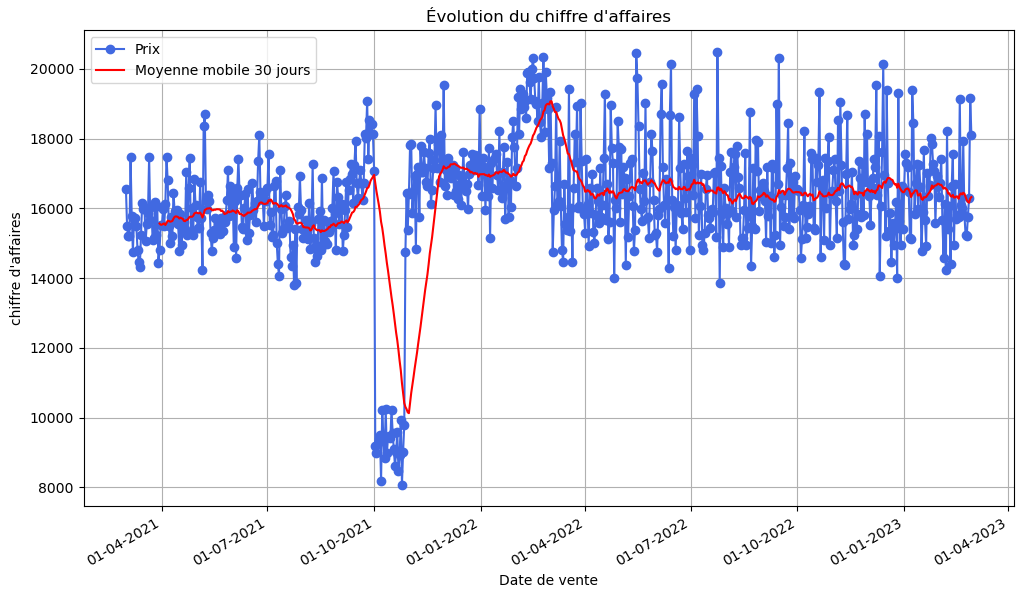

In [627]:

# Création du graphique en ligne
plt.figure(figsize=(12, 7))
plt.plot(data_sorted2['date'], data_sorted2['montant_vente'], marker="o", linestyle='-', color='royalblue', label="Prix")
plt.plot(data_sorted2['date'], data_sorted2['montant_vente'].rolling(30).mean(), linestyle='-', color='red', label="Moyenne mobile 30 jours")



# Formater l'axe des X pour afficher les dates correctement
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()  # Rotation automatique des dates pour une meilleure lisibilité

plt.legend()

plt.title("Évolution du chiffre d'affaires")
plt.xlabel("Date de vente")
plt.ylabel("chiffre d'affaires")
plt.grid(True)
plt.show()

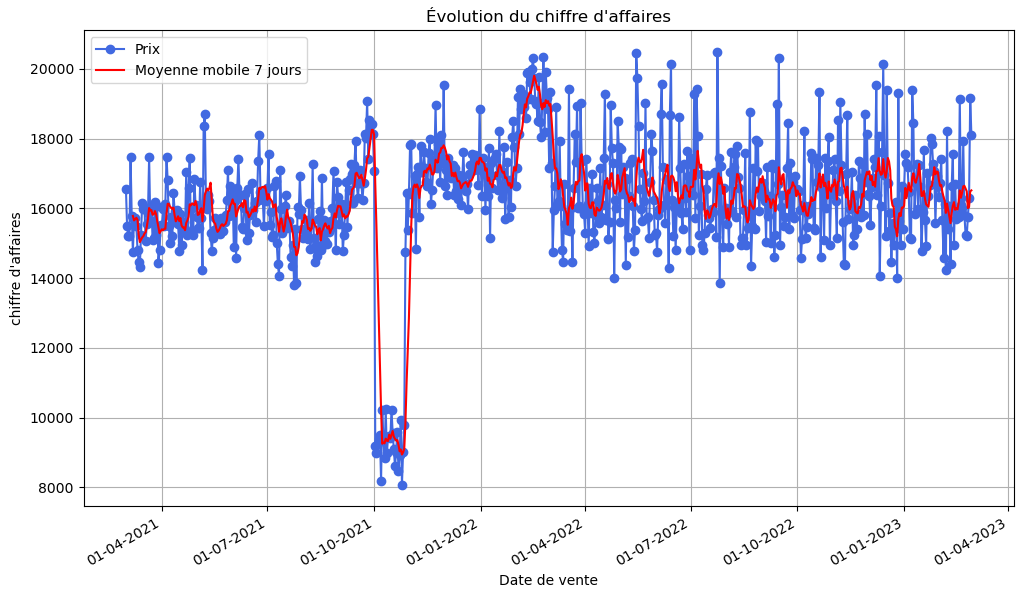

In [629]:
# Evolution du chiffre d'affaires par mois

# Création du graphique en ligne
plt.figure(figsize=(12, 7))
plt.plot(data_sorted2['date'], data_sorted2['montant_vente'], marker="o", linestyle='-', color='royalblue', label="Prix")
plt.plot(data_sorted2['date'], data_sorted2['montant_vente'].rolling(7).mean(), linestyle='-', color='red', label="Moyenne mobile 7 jours")



# Formater l'axe des X pour afficher les dates correctement
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()  # Rotation automatique des dates pour une meilleure lisibilité

plt.legend()

plt.title("Évolution du chiffre d'affaires")
plt.xlabel("Date de vente")
plt.ylabel("chiffre d'affaires")
plt.grid(True)
plt.show()

<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 2.1.2 - Distribution du chiffre d'affaires </h4>

In [632]:
# Calcul de la quantité totale de chaque produit vendu
nbre_produits_vendus = df_trans["id_prod"].value_counts().reset_index(name="qte_totale_vendue")

# Jointure avec la table des prix des produits
df_ca_produits = pd.merge(nbre_produits_vendus, df_prod, on="id_prod", how="left")

# Calcul du chiffre d'affaire par produit
df_ca_produits["ca_produit"] = df_ca_produits["qte_totale_vendue"] * df_ca_produits["price"]

# calcul du chiffre d'affaires total par catégorie de produit
data = df_ca_produits.groupby("categorie_produit")["ca_produit"].sum().reset_index()

# Mettre le chiffre d'affaires en milions
data["ca_produit_en_millions"] = data["ca_produit"] / 1000_000

In [634]:
data

,categorie_produit,ca_produit,ca_produit_en_millions
0,catégorie 0,4419730.97,4.419731
1,catégorie 1,4653722.69,4.653723
2,catégorie 2,2780275.02,2.780275


In [ ]:
# Représenter le chiffre d'affaires par catégorie 

plt.figure(figsize=(16, 8))
plt.pie(x=data["ca_produit_en_millions"], labels=data["categorie_produit"], autopct='%.1f%%')
plt.title("Distribution du chiffre d'affaires selon la cotégorie de produit", color="green", fontweight="bold", fontname="Arial", fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

In [ ]:
# 2e présentation : diagramme à barre

plt.figure(figsize=(12,6))
plt.bar(height=data["ca_produit_en_millions"], x=data["categorie_produit"])

plt.title("Distribution du chiffre d'affaires selon la catégorie de produit",
          color="green", fontweight="bold", fontname="Arial", fontsize=12)
plt.xlabel("Catégorie de produit", fontweight ="bold")
plt.ylabel("Chiffre d'affaires (en mliions d'euros)", fontweight ="bold")
plt.xticks(rotation=0, ha='right')  # ha='right' = alignement à droite


# Afficher les valeurs associées à chaque type de produit

val_niv = data["ca_produit_en_millions"].tolist()

for i in range(3):
    plt.text(i-0.1, val_niv[i]+0.1, round(val_niv[i]))

plt.show()